#**Handeling Outliers**

**Things to see:**

--Winsoraization or caping method,

--log transform,

--power transformer - boxcox,

--standard scaller,

--min max scaller.

**Winsorazation**

Winsorization is a way of handling the impact of extreme values or outliers.

The statistical method involves capping your data and replacing the most extreme points(those that don’t fit the rest of your data) with less extreme values from the same dataset.

if you winsorize the top and bottom 5% of your data, the highest 5% of values would be capped at the 95th percentile and the lowest 5% would be set to the 5th percentile.

Steps

1. Set boundarys

    Your boundary is typically expressed as a percentage, such as 1%, 5%, or 10%. These percentages determine your upper and lower limits (i.e., where you will cap your data).

    lower percentage - minimizes the influence of extreme outliers, higher percentage - allows for more data variation but risks      keeping those unusual values.

2. Find the outliers

    Using your chosen boundary, identify the corresponding percentile values in your dataset. For a 5% winsorization, you’d find the 5th and 95th percentile values. For a 10% winsorization, the 10th and 90th.

    Any data points below the lower bound or above the upper bound are tagged as outliers for adjustment.

3. Adjust extreme values

    Values below the lower are increased to match the lower cutoff point.

    Values above the upper bound are decreased to match the upper cutoff point.

4.Use for analysis

    After replacing the extreme values, you now have a winsorized dataset. This new set has the same number of data points as the original but with the outliers tamed.

    Double-check your work by comparing the summary statistics of your original and winsorized datasets. You will see reduced variance and a narrower range but similar central tendencies—the overall shape of your data should look the same.

    Once verified, use this winsorized dataset in your experimental analysis. The data provides results that are less affected by extreme outliers.


In [11]:
import pandas as pd
import numpy as np
df=pd.read_csv('/content/drive/MyDrive/MLT/preprocessing_dataset.csv')
dfcopy=df

In [12]:
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize

In [13]:
winsored_age=winsorize(df['Age'], (0.1, 0.1))

Text(0.5, 1.0, 'wisored age')

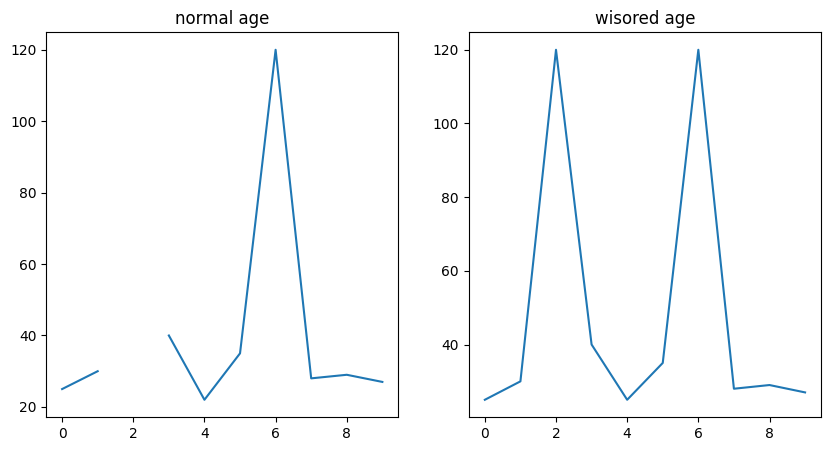

In [14]:
fig,(ax1, ax2)=plt.subplots(1,2,figsize=(10,5))

ax1.plot(df['Age'])
ax1.set_title("normal age")
ax2.plot(winsored_age)
ax2.set_title("wisored age")


**log transformation, standard scaller, minmax scaller**

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*98ZOLihgAbWdFX7_TTnM7w.png" width=400/>

**Feature transformation** - modifying the representation of features to make them more suitable for modeling

**Log normalization**

that handles continuous variables with right-skewed or positively skewed distributions.

This method involves taking the logarithm of each data point.

resulting in a more symmetrical distribution making the data better for modelling


In [15]:
logedage=np.log(df['Age'])

In [16]:
print(df['Age'])

0     25.0
1     30.0
2      NaN
3     40.0
4     22.0
5     35.0
6    120.0
7     28.0
8     29.0
9     27.0
Name: Age, dtype: float64


In [17]:
print(logedage)

0    3.218876
1    3.401197
2         NaN
3    3.688879
4    3.091042
5    3.555348
6    4.787492
7    3.332205
8    3.367296
9    3.295837
Name: Age, dtype: float64


Text(0.5, 1.0, 'loged age')

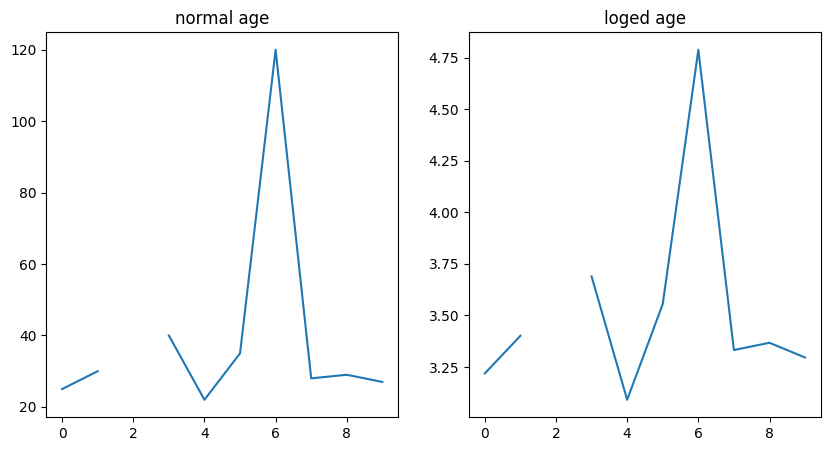

In [18]:
fig,(ax1, ax2)=plt.subplots(1,2,figsize=(10,5))

ax1.plot(df['Age'])
ax1.set_title("normal age")
ax2.plot(logedage)
ax2.set_title("loged age")


**min max scaller**

  Transforms data to reassign each value to fall within the range [0, 1].

  When applied to a feature, the feature’s

    min value becomes zero,
    max value is one.
    
  For each data point’s feature value, subtract the minimum value and divide by the range

  Xi normalized = (Xi-Xmin) / (Xmax-Xmin)





In [19]:
from sklearn.preprocessing import MinMaxScaler

ms=MinMaxScaler()

agecopy=ms.fit_transform(df[['Age']])

In [20]:
print(df['Age'])

0     25.0
1     30.0
2      NaN
3     40.0
4     22.0
5     35.0
6    120.0
7     28.0
8     29.0
9     27.0
Name: Age, dtype: float64


In [21]:
print(agecopy)

[[0.03061224]
 [0.08163265]
 [       nan]
 [0.18367347]
 [0.        ]
 [0.13265306]
 [1.        ]
 [0.06122449]
 [0.07142857]
 [0.05102041]]


Text(0.5, 1.0, 'scaled age')

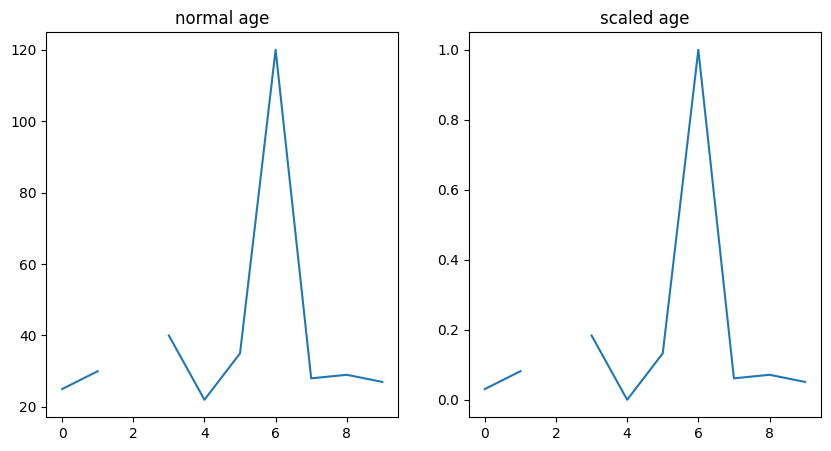

In [22]:
fig,(ax1, ax2)=plt.subplots(1,2,figsize=(10,5))

ax1.plot(df['Age'])
ax1.set_title("normal age")
ax2.plot(agecopy)
ax2.set_title("scaled age")


**Standard scaller**

Transforms each value within a feature so they collectively have a mean of zero and standard deviation of one.

While Min-Max scaling can be sensitive to outliers, standard scaling is less affected because it relies on the mean and standard deviation of the data.

Outliers can still influence the scaling, but not as much as with Min-Max scaling.

Xi standardization = (Xi-Xmean) / (Xstd)

In [23]:
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()
scaledage=sc.fit_transform(df[['Age']])

In [24]:
print(scaledage)

[[-0.50401021]
 [-0.33087693]
 [        nan]
 [ 0.01538962]
 [-0.60789017]
 [-0.15774365]
 [ 2.78552206]
 [-0.40013024]
 [-0.36550359]
 [-0.4347569 ]]


In [25]:
print(df['Age'])

0     25.0
1     30.0
2      NaN
3     40.0
4     22.0
5     35.0
6    120.0
7     28.0
8     29.0
9     27.0
Name: Age, dtype: float64


Text(0.5, 1.0, 'scaled age')

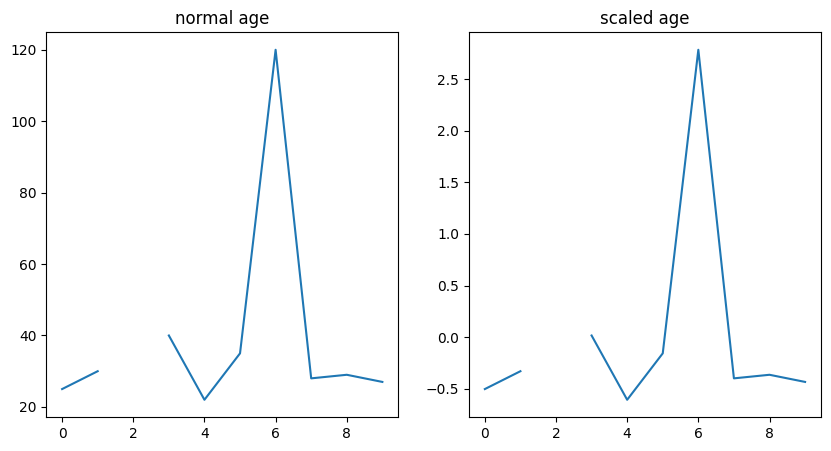

In [26]:
fig,(ax1, ax2)=plt.subplots(1,2,figsize=(10,5))

ax1.plot(df['Age'])
ax1.set_title("normal age")
ax2.plot(scaledage)
ax2.set_title("scaled age")


**Power Transformation**

right-skewed, left-skewed, or leptokurtic

used to make skewed data more normal (Gaussian).

It stabilizes variance, reduces skewness, and gently reshapes those uneven curves into smoother, more symmetrical Gaussian-like mountains.

It adjusts each value in a way that:

    reduces extreme differences between values
    makes patterns more linear
    decreases the impact of outliers
    makes the feature distribution more symmetrical

Why Do We Need Power Transformation?

    Many machine learning algorithms assume the data it Normally
    distributed, linear and evenly spread. But in reality data is
    rarely like that. It’s usually: heavily skewed, full of extreme
    values and unevenly distributed

    Power transformation helps fix these issues so your model can:
    learn better,
    converge faster,
    make more accurate predictions.

Why Do Many ML Models Prefer Normal or Linear Data?

Most machine learning algorithms internally assume that data behaves in a predictable, linear, and well-spread way.

When the feature distribution is normal (or close to normal):

    Gradient-based models converge faster
    Linear models interpret patterns more correctly
    Distance-based algorithms (KNN, clustering) measure similarity
    more accurately
    Outliers create fewer distortions
    Model coefficients become more stable

In short, the more “regular” your data looks, the better your model learns. Power transformation helps achieve exactly that.

**Types of Power Transformations**

**Box–Cox Transformation:**

    Works only for positive values

    Strongly compresses large numbers

    Makes the curve more rounded and uniform

    The “mountain peak” becomes softer

    Tries different powers (λ values) and chooses the one that makes
    data closest to normal

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/0*Y-FqC_I9BFSQHA1K.png" width=200/>

Lambda(𝜆): determine the power transformation applied to the data.

**No transformation** - If 𝜆 = 1 , the formula becomes y¹-1/1=y-1. The subtraction of 1 is just a linear shift, so 𝜆=1 is equivalent to no transformation in terms of its distribution shape.
Other common transformation:

𝜆=1/2 - corresponds to a **square root transformation**.

𝜆=0 - corresponds to natural **logarithm transformation**.

𝜆=-1 - corresponds to a **reciprocal transformation**(1/y).

In [27]:
from sklearn.preprocessing import PowerTransformer

boxcox=PowerTransformer(method='box-cox')
boxcoxage=boxcox.fit_transform(df[['Age']])

Text(0.5, 1.0, 'boscox age')

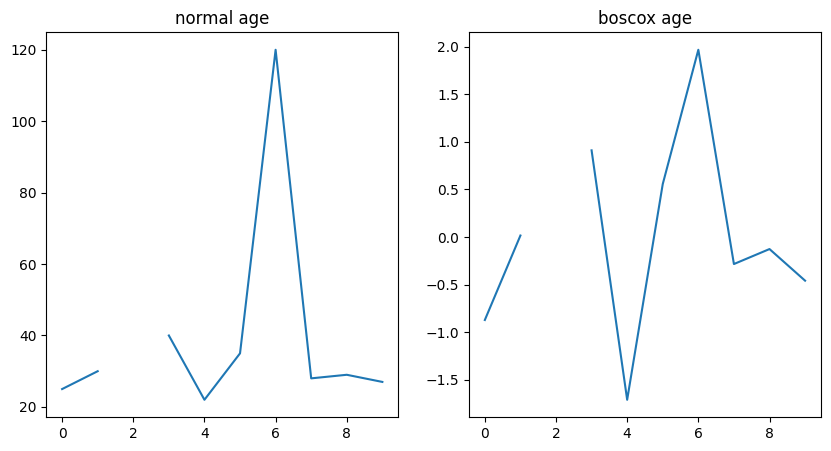

In [28]:
fig,(ax1, ax2)=plt.subplots(1,2,figsize=(10,5))

ax1.plot(df['Age'])
ax1.set_title("normal age")
ax2.plot(boxcoxage)
ax2.set_title("boscox age")


**Yeo–Johnson Transformation:**

    Works for both negative and positive values

    More flexible for real-world datasets

    Often used by default in sklearn

    Smooths the curve more gently

    Retains the overall shape better but still reduces skewness

If data point is **positive**.

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*V6ycLLL95Mt3P7GDmJGq2Q.jpeg" width=200/>

If data point is **negative**.

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*6ueBTA8o3c4JvsMburDltw.jpeg" width=200/>



In [29]:
from sklearn.preprocessing import PowerTransformer

yeojohnson=PowerTransformer(method='yeo-johnson')
yeojohnsonage=boxcox.fit_transform(df[['Age']])

Text(0.5, 1.0, 'yeojohnson age')

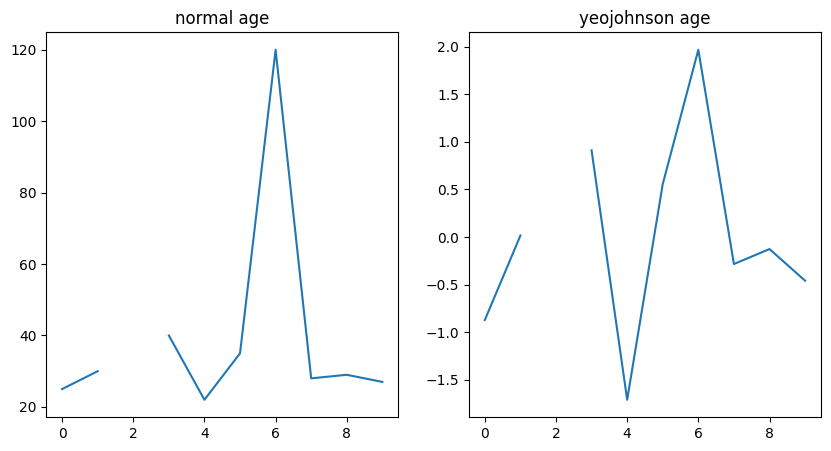

In [30]:
fig,(ax1, ax2)=plt.subplots(1,2,figsize=(10,5))

ax1.plot(df['Age'])
ax1.set_title("normal age")
ax2.plot(boxcoxage)
ax2.set_title("yeojohnson age")


In [31]:
print(df)

      Name    Age Gender   Salary Department
0    Alice   25.0      F  50000.0         HR
1      Bob   30.0      M  60000.0    Finance
2  Charlie    NaN      M  55000.0         IT
3    David   40.0      M  58000.0         HR
4      Eve   22.0      F  52000.0         IT
5    Frank   35.0    NaN  61000.0    Finance
6    Grace  120.0      F      NaN    Finance
7    Henry   28.0      M  59000.0         HR
8      Ivy   29.0      F  63000.0         IT
9     Jack   27.0      M  62000.0    Finance
